### Question 1.

For each point in the complex plane..
..while others will run off to infinity. Make an image in which your points c that diverge
are given one color and those that stay bounded are given another. Make a second image where the points
are coloured by a colourscale that indicates the iteration number at which the given point diverged.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

"""complex_iterations:
    check what points are bounded in the complex plane and which diverge to inf
    
    Parameters:
    x and y range, num iterations, test_pts
        
    Returns:
    bounded and divergent points

"""

def complex_iterations(x_min, x_max,y_min, y_max, test_pts= 100, iterations = 1000):
    
    # binary grid
    x = np.linspace(x_min, x_max, test_pts)
    y = np.linspace(y_min, y_max, test_pts)
    
    X, Y = np.meshgrid(x, y)
        
    cmplx = X + 1j*Y
    # zero array
    z = cmplx * 0
    
    diverged_iterations = cmplx.real*0 + iterations
    curr = cmplx.real*0 + 1 # active point
    
    for i in range(iterations):
        
        z = curr * (z**2 + cmplx) + (1-curr)*z # z^2 + c 
        
        diverged_c = np.abs(z) > 2 # creates boolean array, checks divergence
        
        curr_diverged = diverged_c * curr
        
        diverged_iterations = (curr_diverged*i)  + (1 - curr_diverged) * diverged_iterations
        
        curr = curr * (1 - diverged_c)
        
    bounded = (diverged_iterations == iterations) # boolean
        
    return bounded, diverged_iterations

        

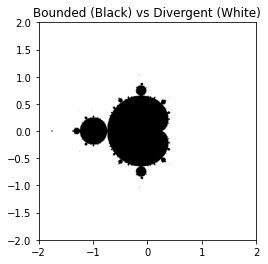

In [5]:
# pre-defined num of iterations loads this kinda slow!!
bounded, iters = complex_iterations(-2, 2, -2, 2, 500)
plt.imshow(bounded, extent=[-2, 2, -2, 2], cmap='binary')
plt.title("Bounded (Black) vs Divergent (White)")
plt.show()

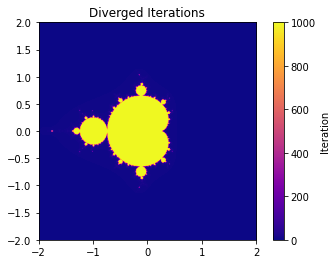

In [6]:
plt.imshow(iters, extent=[-2, 2, -2, 2], cmap='plasma')
plt.colorbar(label='Iteration')
plt.title("Diverged Iterations")
plt.show()

### Question 2.

Lorenz' equations, solve ODE, plot.

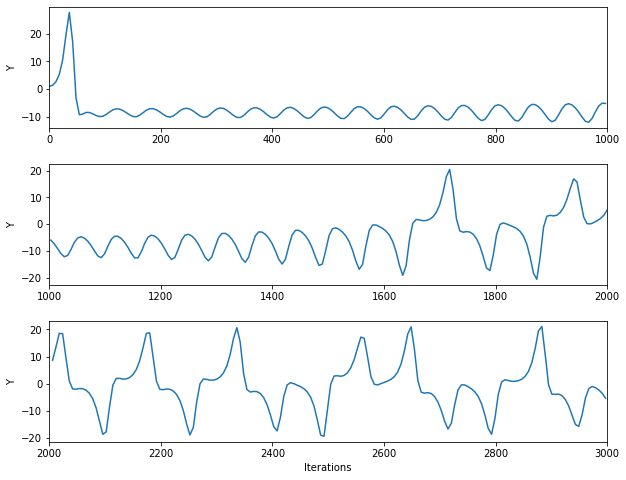

In [48]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

"""
lorenz_eqns:
    Lorenz system of differential equations.
    
    Parameters:
    t (time), state (of variables) , sigma, r , b
        
    Returns:
    list of time derivatives

"""

def lorenz_eqns(t, state, sigma, r, b):
    x, y, z = state
    dx = -sigma * (x-y)
    dy = r * x - y - x * z
    dz = x * y - b * z
    return [dx, dy, dz]

# constants
sigma = 10.
r = 28
b = 8./3.

# 0-60; dimensionless time units
t_span = (0, 60)  
t_eval = np.linspace(0, 60, 1000)

#initial condition
W0 = [0., 1., 0.]   

sol = solve_ivp(fun=lorenz_eqns, t_span= t_span, y0 = W0, args=(sigma, r, b), t_eval = t_eval)

#solved
x = sol.y[0]
y = sol.y[1]
z = sol.y[2]

# lorenz uses N = t/dt, (dt = 0.01)
N = sol.t / 0.01  
y_val = sol.y[1] 

fig, ax = plt.subplots(3, 1, figsize=(10, 8))

# three rows, 1000 iterations each
ax[0].plot(N[0:167], y_val[0:167]) 
ax[0].set_xlim(0, 1000)
ax[0].set_ylabel('Y')

ax[1].plot(N[167:334], y_val[167:334]) 
ax[1].set_xlim(1000, 2000)
ax[1].set_ylabel('Y')

ax[2].plot(N[334:500], y_val[334:500])
ax[2].set_xlim(2000, 3000)
ax[2].set_ylabel('Y')
ax[2].set_xlabel('Iterations')

plt.subplots_adjust(hspace=0.3)
plt.show()

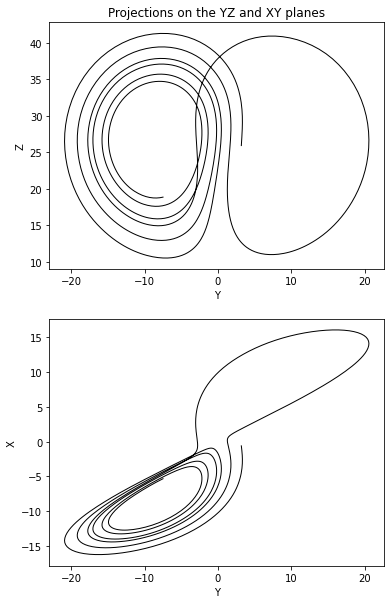

In [77]:
sol = solve_ivp(fun=lorenz_eqns, t_span=(0, 20), y0=W0,args=(sigma, r, b), dense_output=True)

t_eval_2 = np.linspace(14, 19, 1000)
W = sol.sol(t_eval_2)


x2 = W[0]
y2 = W[1]
z2 = W[2]

# creates two panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 10))

#top yz projection
ax1.plot(y2, z2, color='black', linewidth=1)
ax1.set_xlabel('Y')
ax1.set_ylabel('Z')
ax1.set_title('Projections on the YZ and XY planes')

# bottom xy projection
ax2.plot(y2, x2, color='black', linewidth=1)
ax2.set_xlabel('Y')
ax2.set_ylabel('X')

plt.show()

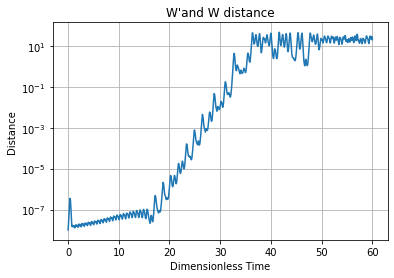

In [75]:
# adding two lists, element by element: https://www.geeksforgeeks.org/python/python-adding-two-list-elements/
w_prime = np.add(W0,[0., 1.e-8, 0])

sol2 = solve_ivp(fun=lorenz_eqns, t_span= t_span, y0 = w_prime, args=(sigma, r, b), t_eval = t_eval)
sol1 = solve_ivp(fun=lorenz_eqns, t_span= t_span, y0 = W0, args=(sigma, r, b), t_eval = t_eval)


w = sol2.y-sol1.y
d = np.linalg.norm(w, axis=0)

#semi-log plot
plt.semilogy(sol1.t, d)
plt.title('W\'and W distance')
plt.xlabel('Dimensionless Time')
plt.ylabel('Distance')
plt.grid(True, which="both", ls="-")
plt.show()
